In [1]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 20.0 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import skfuzzy as fuzz
from skfuzzy import control as ctrl

from google.colab import files

plt.style.use('ggplot')

In [3]:
uploaded = files.upload()

Saving WQD.xlsx to WQD.xlsx


In [5]:
df = pd.read_excel("WQD.xlsx")

In [6]:
df.head()

,Temp,Turbidity (cm),DO(mg/L),BOD (mg/L),CO2,pH`,Alkalinity (mg L-1 ),Hardness (mg L-1 ),Calcium (mg L-1 ),Ammonia (mg L-1 ),Nitrite (mg L-1 ),Phosphorus (mg L-1 ),H2S (mg L-1 ),Plankton (No. L-1),Water Quality
0,67.448725,10.127148,0.208153,7.473607,10.181084,4.751657,218.364855,300.125080,337.178226,0.286054,4.355310,0.005984,0.066793,6069.624017,2
1,64.626666,94.015595,11.434463,10.859998,14.860521,3.085154,273.939692,8.426776,363.660740,0.096040,2.182753,0.004906,0.023428,250.995959,2
2,65.121842,90.653462,12.430865,12.809970,12.319980,9.648515,220.812730,11.726274,309.370934,0.974501,4.901760,0.006979,0.065041,7218.927473,2
3,1.640334,0.066344,10.963529,8.508023,12.955209,4.819988,266.571628,6.627655,8.180468,0.884865,3.571842,3.174473,0.026018,1230.062252,2
4,64.863434,2.119173,1.361736,13.335372,13.603197,10.244034,252.108000,339.891514,253.996871,0.801695,4.655898,3.854701,0.060995,1035.054820,2


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4300 entries, 0 to 4299
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temp                  4300 non-null   float64
 1   Turbidity (cm)        4300 non-null   float64
 2   DO(mg/L)              4300 non-null   float64
 3   BOD (mg/L)            4300 non-null   float64
 4   CO2                   4300 non-null   float64
 5   pH`                   4300 non-null   float64
 6   Alkalinity (mg L-1 )  4300 non-null   float64
 7   Hardness (mg L-1 )    4300 non-null   float64
 8   Calcium (mg L-1 )     4300 non-null   float64
 9   Ammonia (mg L-1 )     4300 non-null   float64
 10  Nitrite (mg L-1 )     4300 non-null   float64
 11  Phosphorus (mg L-1 )  4300 non-null   float64
 12  H2S (mg L-1 )         4300 non-null   float64
 13  Plankton (No. L-1)    4300 non-null   float64
 14  Water Quality         4300 non-null   int64  
dtypes: float64(14), int64

In [8]:
df.describe()

,Temp,Turbidity (cm),DO(mg/L),BOD (mg/L),CO2,pH`,Alkalinity (mg L-1 ),Hardness (mg L-1 ),Calcium (mg L-1 ),Ammonia (mg L-1 ),Nitrite (mg L-1 ),Phosphorus (mg L-1 ),H2S (mg L-1 ),Plankton (No. L-1),Water Quality
count,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000
mean,25.695663,39.046681,5.300346,3.125079,6.375929,7.713468,93.717183,127.055476,84.871932,0.048269,0.642948,1.172749,0.016473,3805.510620,1.023256
std,9.670202,20.942726,1.832736,2.292060,2.831104,1.580282,68.949048,78.883091,75.718842,0.122886,0.903592,1.082648,0.011874,1208.547783,0.820996
min,0.194046,0.051424,0.133928,1.000621,0.001155,0.003944,25.012328,0.255805,0.018293,0.000001,0.000025,0.000128,0.000002,78.603733,0.000000
25%,19.775926,22.224140,3.978366,1.522077,5.048761,6.443019,40.422364,69.479620,23.745078,0.012750,0.010636,0.028355,0.010072,2956.020049,0.000000
50%,25.041849,30.205696,5.000754,2.236022,6.598076,7.743176,67.562607,111.063301,62.845419,0.026335,0.099908,0.975312,0.019049,3729.396476,1.000000
75%,30.277718,55.945735,6.521225,4.324578,8.241532,9.035251,132.834386,162.675648,115.596833,0.039016,1.166714,2.101317,0.019567,4555.089727,2.000000
max,84.251522,99.797743,14.970122,14.943006,14.984216,14.851195,299.913160,398.796550,399.321398,0.999300,4.989535,4.974457,0.099220,7460.415789,2.000000


In [9]:
print(df.isnull().sum())

Temp                    0
Turbidity (cm)          0
DO(mg/L)                0
BOD (mg/L)              0
CO2                     0
pH`                     0
Alkalinity (mg L-1 )    0
Hardness (mg L-1 )      0
Calcium (mg L-1 )       0
Ammonia (mg L-1 )       0
Nitrite (mg L-1 )       0
Phosphorus (mg L-1 )    0
H2S (mg L-1 )           0
Plankton (No. L-1)      0
Water Quality           0
dtype: int64



Duplicate Rows: 0

Statistical Summary:


,Temp,Turbidity (cm),DO(mg/L),BOD (mg/L),CO2,pH`,Alkalinity (mg L-1 ),Hardness (mg L-1 ),Calcium (mg L-1 ),Ammonia (mg L-1 ),Nitrite (mg L-1 ),Phosphorus (mg L-1 ),H2S (mg L-1 ),Plankton (No. L-1),Water Quality
count,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000
mean,25.695663,39.046681,5.300346,3.125079,6.375929,7.713468,93.717183,127.055476,84.871932,0.048269,0.642948,1.172749,0.016473,3805.510620,1.023256
std,9.670202,20.942726,1.832736,2.292060,2.831104,1.580282,68.949048,78.883091,75.718842,0.122886,0.903592,1.082648,0.011874,1208.547783,0.820996
min,0.194046,0.051424,0.133928,1.000621,0.001155,0.003944,25.012328,0.255805,0.018293,0.000001,0.000025,0.000128,0.000002,78.603733,0.000000
25%,19.775926,22.224140,3.978366,1.522077,5.048761,6.443019,40.422364,69.479620,23.745078,0.012750,0.010636,0.028355,0.010072,2956.020049,0.000000
50%,25.041849,30.205696,5.000754,2.236022,6.598076,7.743176,67.562607,111.063301,62.845419,0.026335,0.099908,0.975312,0.019049,3729.396476,1.000000
75%,30.277718,55.945735,6.521225,4.324578,8.241532,9.035251,132.834386,162.675648,115.596833,0.039016,1.166714,2.101317,0.019567,4555.089727,2.000000
max,84.251522,99.797743,14.970122,14.943006,14.984216,14.851195,299.913160,398.796550,399.321398,0.999300,4.989535,4.974457,0.099220,7460.415789,2.000000


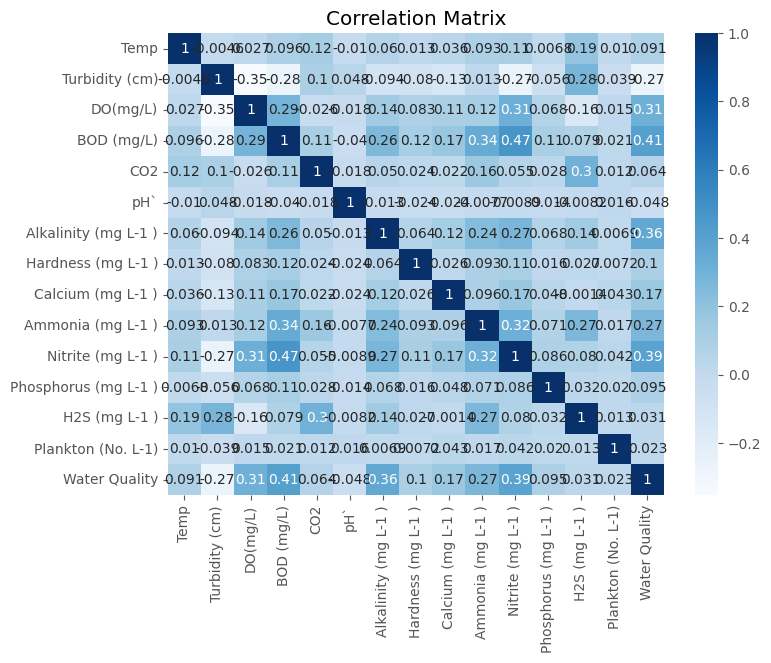

In [10]:
print("\nDuplicate Rows:", df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe())

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues')
plt.title("Correlation Matrix")
plt.show()

In [11]:
# ===============================
# Define Fuzzy Variables
# ===============================

# Input Variables
pH = ctrl.Antecedent(np.arange(0, 15, 0.1), 'pH')
DO = ctrl.Antecedent(np.arange(0, 15, 0.1), 'Dissolved_Oxygen')
Turbidity = ctrl.Antecedent(np.arange(0, 11, 0.1), 'Turbidity')

# Output Variable
WQI = ctrl.Consequent(np.arange(0, 101, 1), 'WQI')

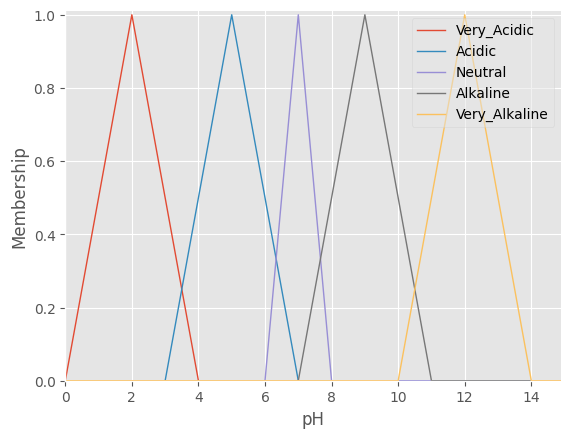

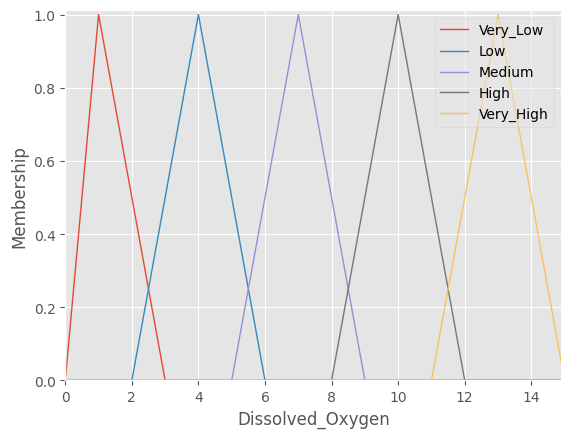

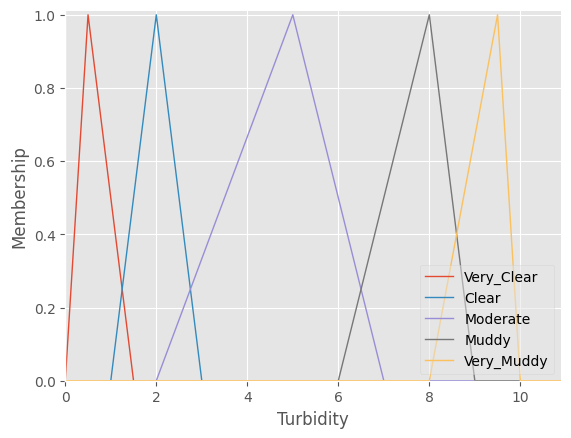

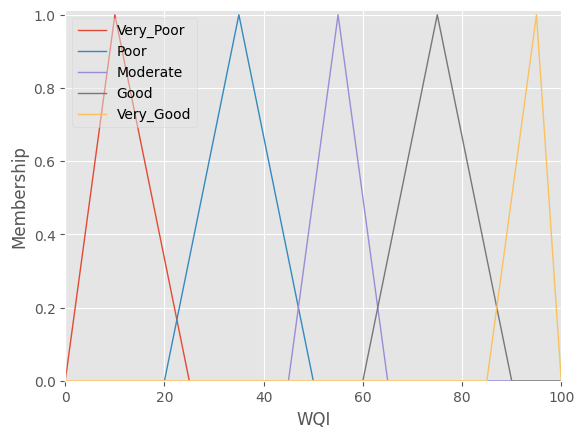

In [12]:
# ===============================
# Membership Functions
# ===============================

# pH
pH['Very_Acidic'] = fuzz.trimf(pH.universe, [0, 2, 4])
pH['Acidic'] = fuzz.trimf(pH.universe, [3, 5, 7])
pH['Neutral'] = fuzz.trimf(pH.universe, [6, 7, 8])
pH['Alkaline'] = fuzz.trimf(pH.universe, [7, 9, 11])
pH['Very_Alkaline'] = fuzz.trimf(pH.universe, [10, 12, 14])

# Dissolved Oxygen
DO['Very_Low'] = fuzz.trimf(DO.universe, [0, 1, 3])
DO['Low'] = fuzz.trimf(DO.universe, [2, 4, 6])
DO['Medium'] = fuzz.trimf(DO.universe, [5, 7, 9])
DO['High'] = fuzz.trimf(DO.universe, [8, 10, 12])
DO['Very_High'] = fuzz.trimf(DO.universe, [11, 13, 15])

# Turbidity
Turbidity['Very_Clear'] = fuzz.trimf(Turbidity.universe, [0, 0.5, 1.5])
Turbidity['Clear'] = fuzz.trimf(Turbidity.universe, [1, 2, 3])
Turbidity['Moderate'] = fuzz.trimf(Turbidity.universe, [2, 5, 7])
Turbidity['Muddy'] = fuzz.trimf(Turbidity.universe, [6, 8, 9])
Turbidity['Very_Muddy'] = fuzz.trimf(Turbidity.universe, [8, 9.5, 10])

# Water Quality Index
WQI['Very_Poor'] = fuzz.trimf(WQI.universe, [0, 10, 25])
WQI['Poor'] = fuzz.trimf(WQI.universe, [20, 35, 50])
WQI['Moderate'] = fuzz.trimf(WQI.universe, [45, 55, 65])
WQI['Good'] = fuzz.trimf(WQI.universe, [60, 75, 90])
WQI['Very_Good'] = fuzz.trimf(WQI.universe, [85, 95, 100])

# View Membership Functions
pH.view()
DO.view()
Turbidity.view()
WQI.view()

In [13]:
# ===============================
# Fuzzy Rules
# ===============================

Rules = [

    # Very Poor Water Quality
    ctrl.Rule(pH['Very_Acidic'] & DO['Very_Low'] & Turbidity['Very_Muddy'], WQI['Very_Poor']),
    ctrl.Rule(pH['Very_Acidic'] & DO['Low'] & Turbidity['Muddy'], WQI['Poor']),
    ctrl.Rule(pH['Very_Alkaline'] & DO['Very_Low'] & Turbidity['Muddy'], WQI['Poor']),

    # Poor Water Quality
    ctrl.Rule(pH['Acidic'] & DO['Low'] & Turbidity['Muddy'], WQI['Poor']),
    ctrl.Rule(pH['Neutral'] & DO['Low'] & Turbidity['Muddy'], WQI['Poor']),
    ctrl.Rule(pH['Very_Acidic'] & DO['Medium'] & Turbidity['Muddy'], WQI['Poor']),

    # Moderate Water Quality
    ctrl.Rule(pH['Acidic'] & DO['Medium'] & Turbidity['Moderate'], WQI['Moderate']),
    ctrl.Rule(pH['Neutral'] & DO['Medium'] & Turbidity['Moderate'], WQI['Moderate']),
    ctrl.Rule(pH['Alkaline'] & DO['Low'] & Turbidity['Muddy'], WQI['Moderate']),
    ctrl.Rule(pH['Very_Alkaline'] & DO['Low'] & Turbidity['Muddy'], WQI['Moderate']),
    ctrl.Rule(pH['Very_Acidic'] & DO['High'] & Turbidity['Clear'], WQI['Moderate']),
    ctrl.Rule(pH['Very_Acidic'] & DO['Very_High'] & Turbidity['Clear'], WQI['Moderate']),

    # Good Water Quality
    ctrl.Rule(pH['Acidic'] & DO['High'] & Turbidity['Clear'], WQI['Good']),
    ctrl.Rule(pH['Neutral'] & DO['Medium'] & Turbidity['Very_Clear'], WQI['Good']),
    ctrl.Rule(pH['Alkaline'] & DO['Medium'] & Turbidity['Moderate'], WQI['Good']),
    ctrl.Rule(pH['Very_Alkaline'] & DO['Medium'] & Turbidity['Moderate'], WQI['Good']),
    ctrl.Rule(pH['Acidic'] & DO['Very_High'] & Turbidity['Clear'], WQI['Good']),

    # Missing Rule (Fixed)
    ctrl.Rule(pH['Neutral'] & DO['Medium'] & Turbidity['Clear'], WQI['Good']),

    ctrl.Rule(pH['Alkaline'] & DO['Medium'] & Turbidity['Clear'], WQI['Good']),
    ctrl.Rule(pH['Acidic'] & DO['Medium'] & Turbidity['Clear'], WQI['Good']),
    ctrl.Rule(pH['Neutral'] & DO['High'] & Turbidity['Moderate'], WQI['Good']),

    # Very Good Water Quality
    ctrl.Rule(pH['Neutral'] & DO['High'] & Turbidity['Clear'], WQI['Very_Good']),
    ctrl.Rule(pH['Neutral'] & DO['Very_High'] & Turbidity['Clear'], WQI['Very_Good']),
    ctrl.Rule(pH['Alkaline'] & DO['High'] & Turbidity['Clear'], WQI['Very_Good']),
    ctrl.Rule(pH['Very_Alkaline'] & DO['High'] & Turbidity['Clear'], WQI['Very_Good'])
]

print("Total Rules:", len(Rules))

Total Rules: 25


Enter Water Quality Parameters
Enter pH Value: 6
Enter Dissolved Oxygen (mg/L): 11
Enter Turbidity (NTU): 2

Predicted Water Quality Index (WQI): 75.00
Water Quality : Good


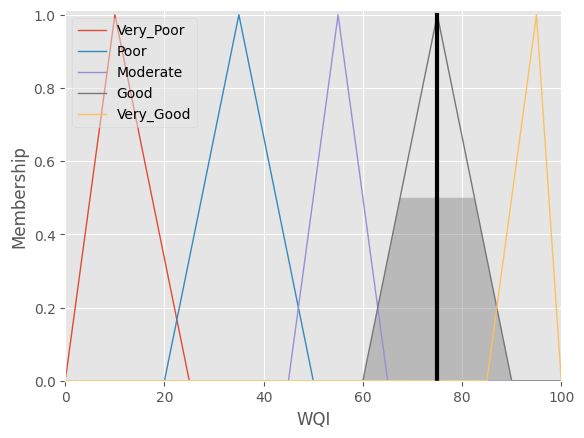

In [14]:
# ===============================
# Create Fuzzy Control System
# ===============================

wqi_ctrl = ctrl.ControlSystem(Rules)
wqi_simulation = ctrl.ControlSystemSimulation(wqi_ctrl)

# ===============================
# User Input
# ===============================

print("Enter Water Quality Parameters")

ph_value = float(input("Enter pH Value: "))
do_value = float(input("Enter Dissolved Oxygen (mg/L): "))
turbidity_value = float(input("Enter Turbidity (NTU): "))

# ===============================
# Assign Inputs
# ===============================

wqi_simulation.input['pH'] = ph_value
wqi_simulation.input['Dissolved_Oxygen'] = do_value
wqi_simulation.input['Turbidity'] = turbidity_value

# ===============================
# Compute WQI
# ===============================

wqi_simulation.compute()

# ===============================
# Display Result
# ===============================

predicted_wqi = wqi_simulation.output['WQI']

print("\nPredicted Water Quality Index (WQI): {:.2f}".format(predicted_wqi))

# ===============================
# Water Quality Category
# ===============================

if predicted_wqi < 25:
    print("Water Quality : Very Poor")
elif predicted_wqi < 50:
    print("Water Quality : Poor")
elif predicted_wqi < 65:
    print("Water Quality : Moderate")
elif predicted_wqi < 90:
    print("Water Quality : Good")
else:
    print("Water Quality : Very Good")

# ===============================
# Visualize Output
# ===============================

WQI.view(sim=wqi_simulation)
plt.show()